In [ ]:
# ============= PROYEKSI TUTUPAN LAHAN 2026 =============
# Nama    : Afif Janur
# Data    : Hasil klasifikasi tutupan lahan 2020 dan 2023
# Metode  : Cellular Automata-Makrov
# Hasil   : Proyeksi Tutupan Lahan 2026
# ============================================================
# 1. INSTALL
# ============================================================
!pip install rasterio geopandas scikit-learn pandas matplotlib seaborn openpyxl shapely

In [ ]:
# ============================================================
# 2. IMPORT LIBRARY
# ============================================================

import os
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
import matplotlib.pyplot as plt

from rasterio.mask import mask

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    cohen_kappa_score,
    classification_report
)

from google.colab import drive



In [ ]:
# ============================================================
# 3. HUBUNGKAN KE GOOGLE DRIVE
# ============================================================

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ============================================================
# 4. MENCARI LOKASI DATA
# ============================================================

DATA_DIR = "/content/drive/MyDrive/Prediksi"

RASTER_2020 = os.path.join(
    DATA_DIR,
    "landcover_2020.tif"
)

RASTER_2023 = os.path.join(
    DATA_DIR,
    "landcover_2023.tif"
)


OUTPUT_DIR = os.path.join(
    DATA_DIR,
    "hasil_proyek"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

In [ ]:
# ============================================================
# 5. MENGECEK DATA LANDCOVER 2020 DAN 2023
# ============================================================
with rasterio.open(RASTER_2020) as src:

    lc2020 = src.read(1)

    profile = src.profile.copy()
    transform = src.transform
    crs = src.crs
    nodata_2020 = src.nodata

with rasterio.open(RASTER_2023) as src:

    lc2023 = src.read(1)

    nodata_2023 = src.nodata

print("Ukuran raster 2020:", lc2020.shape)
print("Ukuran raster 2023:", lc2023.shape)

print("CRS:", crs)

print("Resolusi:",
      transform.a,
      "x",
      abs(transform.e),
      "meter")



Ukuran raster 2020: (6789, 5075)
Ukuran raster 2023: (6789, 5075)
CRS: EPSG:4326
Resolusi: 8.983152841195139e-05 x 8.983152841195207e-05 meter


In [ ]:
# ============================================================
# 6. MENGECEK KELAS TUTUPAN LAHAN
# ============================================================
classes = {
    1: "Air",
    2: "Vegetasi",
    3: "Permukiman"
}

print("Kelas 2020:")
print(np.unique(lc2020))

print("\nKelas 2023:")
print(np.unique(lc2023))


class_ids = [1, 2, 3]

valid = (
    np.isin(lc2020, class_ids)
    &
    np.isin(lc2023, class_ids)
)

transition_count = np.zeros(
    (3, 3),
    dtype=np.int64
)

for i, class_from in enumerate(class_ids):

    for j, class_to in enumerate(class_ids):

        transition_count[i, j] = np.sum(
            (lc2020 == class_from)
            &
            (lc2023 == class_to)
            &
            valid
        )

transition_df = pd.DataFrame(
    transition_count,
    index=["Air", "Vegetasi", "Permukiman"],
    columns=["Air", "Vegetasi", "Permukiman"]
)

print(transition_df)


Kelas 2020:
[1 2 3]

Kelas 2023:
[1 2 3]
                 Air  Vegetasi  Permukiman
Air         16784915    190485       12523
Vegetasi       22284   9781296     2255409
Permukiman      2001    988263     4416999


In [ ]:
# ============================================================
# 7. MEMBUAT MATRIK TRANSISI
# ============================================================
transition_df.to_excel(
    os.path.join(
        output_dir,
        "01_matriks_transisi_2020_2023.xlsx"
    )
)


In [ ]:
# ============================================================
# 8. MENGHITUNG PROBABILITAS TRANSISI
# ============================================================
transition_probability = np.zeros(
    (3, 3),
    dtype=float
)

for i in range(3):

    total = transition_count[i].sum()

    if total > 0:

        transition_probability[i] = (
            transition_count[i] / total
        )

probability_df = pd.DataFrame(
    transition_probability,
    index=["Air", "Vegetasi", "Permukiman"],
    columns=["Air", "Vegetasi", "Permukiman"]
)

print(
    probability_df.round(4)
)

probability_df.to_excel(
    os.path.join(
        output_dir,
        "02_probabilitas_transisi.xlsx"
    )
)

               Air  Vegetasi  Permukiman
Air         0.9880    0.0112      0.0007
Vegetasi    0.0018    0.8111      0.1870
Permukiman  0.0004    0.1828      0.8169


Markov digunakan untuk menghitung probabilitas perubahan kelas tutupan lahan berdasarkan perubahan yang terjadi pada periode sebelumnya. Probabilitas tersebut kemudian digunakan untuk memperkirakan berapa luas setiap kelas yang akan ada pada periode mendatang. Jadi, Markov lebih menjawab pertanyaan: "Berapa banyak lahan yang kemungkinan berubah dari kelas A menjadi kelas B?"

In [ ]:
# ============================================================
# 9. PROYEKSI LUAS 2026
# ============================================================
current_area = np.array([
    np.sum(
        (lc2023 == c)
        &
        valid
    )
    for c in class_ids
])

future_area = (
    current_area
    @
    transition_probability
)

projection_df = pd.DataFrame({

    "Kelas": [
        "Air",
        "Vegetasi",
        "Permukiman"
    ],

    "Pixel_2023": current_area,

    "Pixel_Proyeksi_2026": future_area

})

print(projection_df)

pixel_width = abs(transform.a)
pixel_height = abs(transform.e)

pixel_area_m2 = (
    pixel_width *
    pixel_height
)

projection_df["Luas_2026_m2"] = (
    projection_df["Pixel_Proyeksi_2026"]
    *
    pixel_area_m2
)

projection_df["Luas_2026_ha"] = (
    projection_df["Luas_2026_m2"]
    /
    10000
)

print(projection_df)

projection_df.to_excel(
    os.path.join(
        output_dir,
        "03_proyeksi_luas_2026.xlsx"
    ),
    index=False
)


        Kelas  Pixel_2023  Pixel_Proyeksi_2026
0         Air    16809200         1.663105e+07
1    Vegetasi    10960044         1.030018e+07
2  Permukiman     6684931         7.522943e+06
        Kelas  Pixel_2023  Pixel_Proyeksi_2026  Luas_2026_m2  Luas_2026_ha
0         Air    16809200         1.663105e+07      0.134208      0.000013
1    Vegetasi    10960044         1.030018e+07      0.083119      0.000008
2  Permukiman     6684931         7.522943e+06      0.060708      0.000006


In [ ]:
# ============================================================
# 10. SIMULASI SPASIAL 2026
# ============================================================
def neighborhood_density(
    raster,
    class_id
):

    binary = (
        raster == class_id
    ).astype(float)

    padded = np.pad(
        binary,
        1,
        mode="edge"
    )

    density = np.zeros_like(
        binary,
        dtype=float
    )

    for dx in range(3):

        for dy in range(3):

            density += padded[
                dx:dx + binary.shape[0],
                dy:dy + binary.shape[1]
            ]

    density -= binary

    return density / 8

density = {}

for c in class_ids:

    print(
        "Menghitung:",
        classes[c]
    )

    density[c] = neighborhood_density(
        lc2023,
        c
    )


Menghitung: Air
Menghitung: Vegetasi
Menghitung: Permukiman


In [ ]:
# ============================================================
# 11. SIMULASI CA
# ============================================================
prediction = lc2023.copy()

rng = np.random.default_rng(42)

markov_weight = 0.4
neighborhood_weight = 0.6

iterations = 3

target_count = future_area

for iteration in range(iterations):

    print(
        f"Iterasi {iteration + 1}/{iterations}"
    )

    new_prediction = prediction.copy()

    current_count = np.array([
        np.sum(
            (prediction == c)
            &
            valid
        )
        for c in class_ids
    ])

    demand = (
        target_count -
        current_count
    )

    rows, cols = np.where(valid)

    for i, j in zip(rows, cols):

        current_class = prediction[i, j]

        current_index = (
            class_ids.index(
                current_class
            )
        )

        scores = np.zeros(3)

        for k, target_class in enumerate(
            class_ids
        ):

            markov_score = (
                transition_probability[
                    current_index,
                    k
                ]
            )

            neighborhood_score = (
                density[
                    target_class
                ][i, j]
            )

            if target_count[k] > 0:

                demand_score = max(
                    demand[k],
                    0
                ) / target_count[k]

            else:

                demand_score = 0

            scores[k] = (

                markov_weight *
                markov_score

                +

                neighborhood_weight *
                neighborhood_score

                +

                0.2 *
                demand_score

            )

        scores += (
            rng.random(3)
            * 0.001
        )

        selected = np.argmax(
            scores
        )

        new_prediction[i, j] = (
            class_ids[selected]
        )

    prediction = new_prediction


Iterasi 1/3
Iterasi 2/3
Iterasi 3/3


Cellular Automata (CA) adalah metode pemodelan yang digunakan untuk menggambarkan perubahan suatu wilayah berdasarkan interaksi antar-sel dalam ruang. Dalam pemodelan tutupan lahan, wilayah dibagi menjadi sel atau piksel, dan perubahan kondisi suatu sel dipengaruhi oleh kondisi sel di sekitarnya serta faktor-faktor spasial seperti jalan, permukiman, dan penggunaan lahan lainnya. Sederhananya, CA digunakan untuk menentukan lokasi atau pola spasial terjadinya perubahan tutupan lahan.

In [ ]:
# ============================================================
# 12. EXPORT HASIL
# ============================================================
import os

output_dir = "/content/drive/MyDrive/Prediksi/hasil_proyeksi_2026"

os.makedirs(output_dir, exist_ok=True)

print("Output directory:")
print(output_dir)

print("\nFolder tersedia:", os.path.exists(output_dir))

# ============================================================
# EXPORT PROYEKSI 2026 KE GOOGLE DRIVE
# ============================================================

import os
import numpy as np
import rasterio

output_raster = os.path.join(
    output_dir,
    "tutupan_lahan_proyeksi_2026.tif"
)

# Profile baru
profile_2026 = {
    "driver": "GTiff",
    "height": prediction.shape[0],
    "width": prediction.shape[1],
    "count": 1,
    "dtype": "uint8",
    "crs": profile["crs"],
    "transform": profile["transform"],
    "nodata": 0,
    "compress": "lzw"
}

with rasterio.open(
    output_raster,
    "w",
    **profile_2026
) as dst:

    dst.write(
        prediction.astype(np.uint8),
        1
    )

print("========================================")
print("RASTER BERHASIL DIEKSPOR")
print("========================================")
print(output_raster)


Output directory:
/content/drive/MyDrive/Prediksi/hasil_proyeksi_2026

Folder tersedia: True
RASTER BERHASIL DIEKSPOR
/content/drive/MyDrive/Prediksi/hasil_proyeksi_2026/tutupan_lahan_proyeksi_2026.tif


Keduanya memiliki fungsi yang berbeda dan saling melengkapi,

Markov → menentukan jumlah/luas perubahan

Cellular Automata → menentukan lokasi perubahan secara spasial

Gabungan dari Markov dan CA dapat menentukan proyeksi peta tutupan lahan 2026

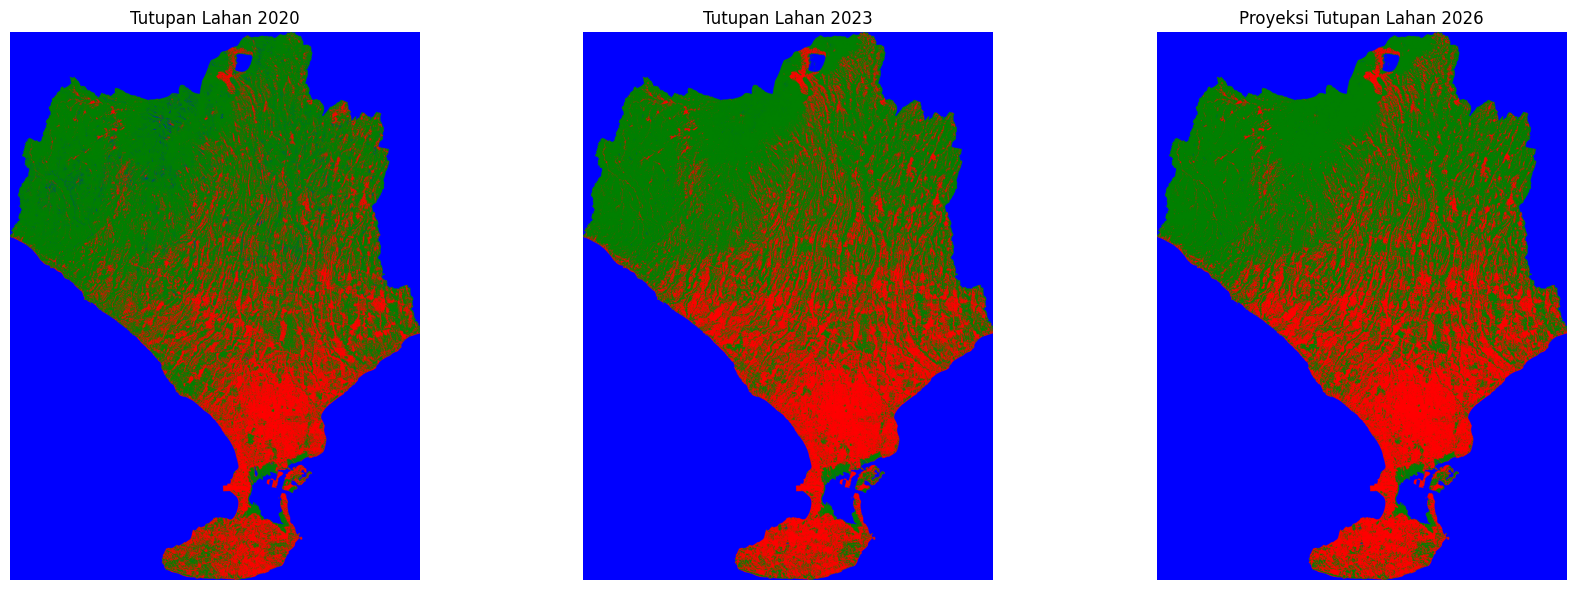

In [ ]:
# ============================================================
# 13. VISUALISASI HASIL
# ============================================================
from matplotlib.colors import ListedColormap

cmap = ListedColormap([
    "blue",    # Air
    "green",   # Vegetasi
    "red"      # Permukiman
])

fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 6)
)

# 2020
axes[0].imshow(
    lc2020,
    cmap=cmap,
    vmin=1,
    vmax=3
)

axes[0].set_title(
    "Tutupan Lahan 2020"
)

axes[0].axis("off")


# 2023
axes[1].imshow(
    lc2023,
    cmap=cmap,
    vmin=1,
    vmax=3
)

axes[1].set_title(
    "Tutupan Lahan 2023"
)

axes[1].axis("off")


# 2026
axes[2].imshow(
    prediction,
    cmap=cmap,
    vmin=1,
    vmax=3
)

axes[2].set_title(
    "Proyeksi Tutupan Lahan 2026"
)

axes[2].axis("off")


plt.tight_layout()

plt.savefig(
    os.path.join(
        output_dir,
        "04_perbandingan_2020_2023_2026.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
